In [13]:
import random
import sys
from PIL import Image
from IPython.display import Video
from pathlib import Path
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from ultralytics import YOLO

# yolo
from yolo_utils import yolo_preprocess_tensor, yolo_video_from_dataset, yolo_postprocess_res

# paths
sys.path.append(str(Path().resolve().parent))
from paths import REPO_ROOT, DATASETS_DIR, POLICIES_DIR, HF_NAME

# magic autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
REPO_NAME       = 'so101_car_pick_and_place'
EXPERIMENT_NAME = 'v0'
DATASET_PATH    = DATASETS_DIR / REPO_NAME
MODEL_PATH      = POLICIES_DIR / 'yolo' / REPO_NAME / EXPERIMENT_NAME / 'best.pt'
vid_path        = REPO_ROOT / 'outputs' / 'yolo' / "episode0_topcam_yolo.mp4"

In [15]:
dataset = LeRobotDataset(f"{HF_NAME}/{REPO_NAME}", root=f"{DATASETS_DIR}/{REPO_NAME}", video_backend='pyav')
model = YOLO(MODEL_PATH)

### 1. Test Inference on video

In [ ]:
out_path = yolo_video_from_dataset(
    model    = model,
    dataset  = dataset,
    episode  = 0,
    fps      = dataset.fps,
    out_path = vid_path
)

In [ ]:
Video(vid_path, embed=True)

Annotate a bunch of images:

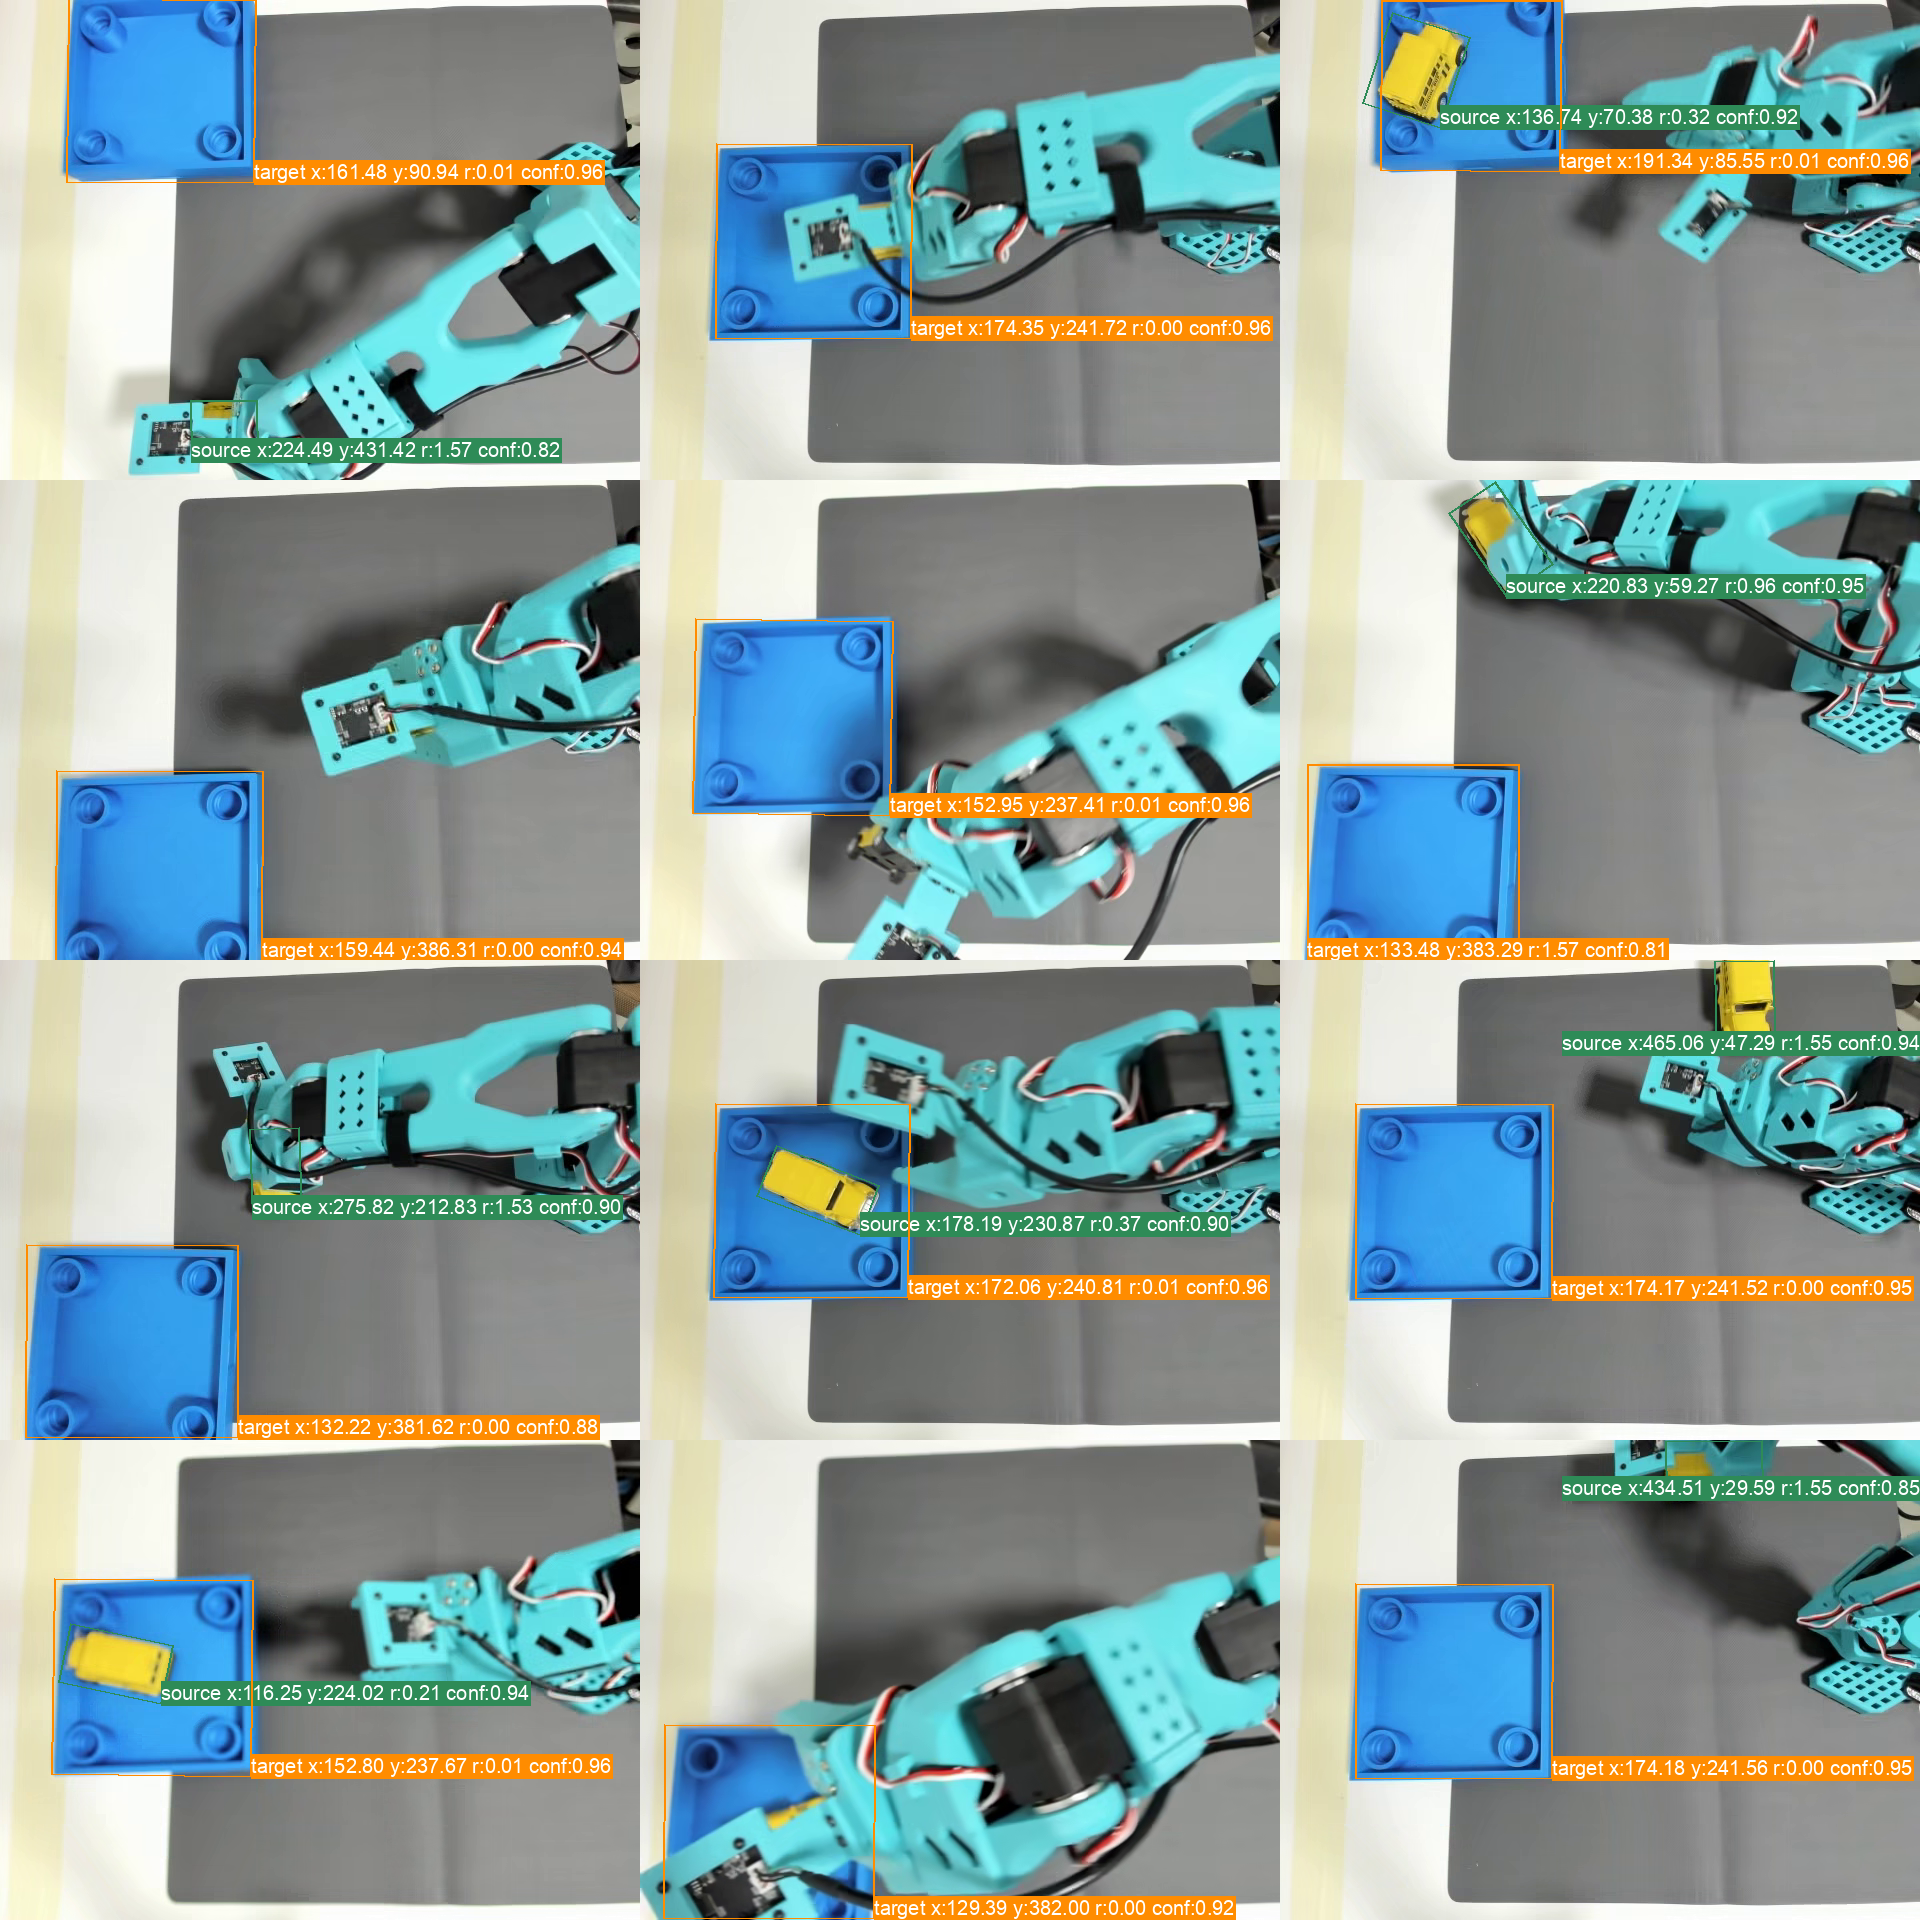

In [32]:
cols = 3
rows = 4

idxs = random.sample(range(len(dataset)), cols * rows)
grid_imgs = [] 

for idx in idxs:
    frame = dataset[idx]["observation.images.top_cam"]
    # preprocess + forward
    rgb = yolo_preprocess_tensor(frame)
    res = model.predict(rgb, conf=0.5, verbose=False)[0]
    # post process
    out, ann = yolo_postprocess_res(res)
    grid_imgs.append(ann)

w, h = grid_imgs[0].size
grid = Image.new("RGB", (cols * w, rows * h))

i = 0
for r in range(rows):
    for c in range(cols):
        grid.paste(grid_imgs[i], (c * w, r * h))
        i += 1

display(grid)

In [34]:
out

[0.6789191365242004,
 0.061649832874536514,
 1.5509889125823975,
 0.27215439081192017,
 0.5032455921173096,
 0.0045775058679282665]